In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('jeruk_balance_500.csv')

df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,7.75,216.4,0.51,11.1,Kalimantan,oranye,kemarau,Bagus
1,7.43,237.9,0.43,10.6,Jawa Tengah,kuning,kemarau,Bagus
2,7.82,195.1,0.60,12.9,Jawa Barat,oranye,hujan,Bagus
3,8.26,184.9,0.49,13.9,Kalimantan,oranye,hujan,Bagus
4,7.38,182.2,0.42,10.6,Jawa Barat,oranye,kemarau,Bagus


## 1. Data Understaining

In [24]:
df.shape

(500, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diameter     500 non-null    float64
 1   berat        500 non-null    float64
 2   tebal_kulit  500 non-null    float64
 3   kadar_gula   500 non-null    float64
 4   asal_daerah  500 non-null    str    
 5   warna        500 non-null    str    
 6   musim_panen  500 non-null    str    
 7   kualitas     500 non-null    str    
dtypes: float64(4), str(4)
memory usage: 44.7 KB


In [8]:
df.describe()

,diameter,berat,tebal_kulit,kadar_gula
count,500.000000,500.000000,500.000000,500.000000
mean,6.514780,150.670600,0.730460,10.020200
std,0.955277,44.637103,0.252194,1.882291
min,3.990000,74.400000,0.270000,5.800000
25%,5.747500,106.000000,0.540000,8.600000
50%,6.540000,151.600000,0.690000,10.100000
75%,7.290000,188.050000,0.882500,11.500000
max,8.730000,277.100000,1.620000,14.600000


In [9]:
df['asal_daerah'].value_counts(True)

asal_daerah
Jawa Tengah    0.388
Kalimantan     0.326
Jawa Barat     0.286
Name: proportion, dtype: float64

In [11]:
df['warna'].value_counts()

warna
hijau     255
kuning    148
oranye     97
Name: count, dtype: int64

In [12]:
df['kualitas'].value_counts()

kualitas
Bagus     168
Sedang    166
Jelek     166
Name: count, dtype: int64

<Axes: xlabel='asal_daerah', ylabel='Count'>

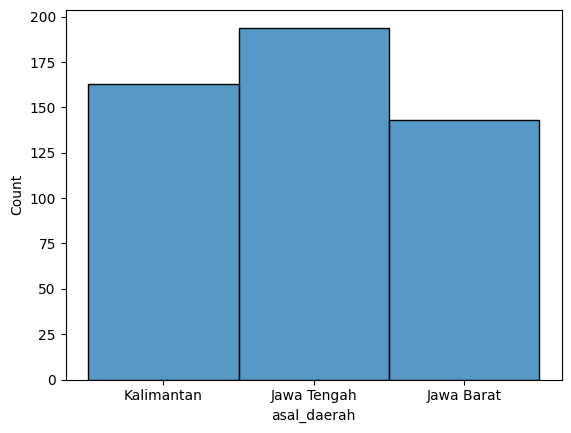

In [18]:
sns.histplot(df['asal_daerah'], label='Asal Daerah')

## 2.Data Cleaning

In [30]:
df.isna().sum()

diameter       0
berat          0
tebal_kulit    0
kadar_gula     0
asal_daerah    0
warna          0
musim_panen    0
kualitas       0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

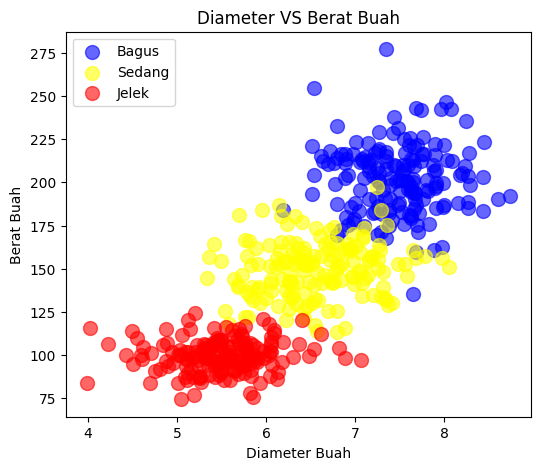

In [31]:
bagus = df[df['kualitas'] == 'Bagus']
sedang = df[df['kualitas'] == 'Sedang']
jelek = df[df['kualitas'] == 'Jelek']

plt.figure(figsize=(6,5))
plt.scatter(bagus['diameter'], bagus['berat'], s=100, alpha=0.6, color='blue', label='Bagus')
plt.scatter(sedang['diameter'], sedang['berat'], s=100, alpha=0.6, color='yellow', label='Sedang')
plt.scatter(jelek['diameter'], jelek['berat'], s=100, color='red', label='Jelek', alpha=0.6)
plt.legend()
plt.title('Diameter VS Berat Buah')
plt.xlabel('Diameter Buah')
plt.ylabel('Berat Buah')
plt.show()

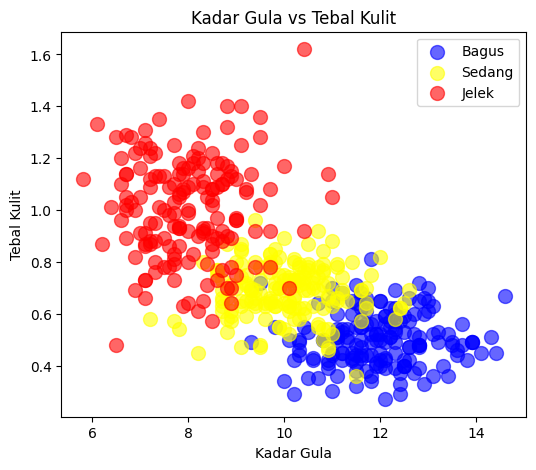

In [32]:
bagus = df[df['kualitas'] == 'Bagus']
sedang = df[df['kualitas'] == 'Sedang']
jelek = df[df['kualitas'] == 'Jelek']

plt.figure(figsize=(6,5))
plt.ylabel('Tebal Kulit')
plt.xlabel('Kadar Gula')
plt.scatter(bagus['kadar_gula'], bagus['tebal_kulit'], s=100, alpha=0.6, color='blue', label='Bagus')
plt.scatter(sedang['kadar_gula'], sedang['tebal_kulit'], s=100, alpha=0.6, color='yellow', label='Sedang')
plt.scatter(jelek['kadar_gula'], jelek['tebal_kulit'], s=100, alpha=0.6, color='red', label='Jelek')
plt.legend()
plt.title('Kadar Gula vs Tebal Kulit')
plt.show()

## 4. Data Preprocessing

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x = df.drop(columns='kualitas')
y = df['kualitas']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

numeric_columns = ['diameter', 'berat', 'tebal_kulit', 'kadar_gula']
category_colums = ['musim_panen', 'asal_daerah']
ordinal_colums = ['warna']

warna_order = ['hijau', 'kuning', 'oranye']
ordinal_order = [warna_order]

preprocessing = ColumnTransformer([
    ('scaler', StandardScaler(), numeric_columns),
    ('ohe', OneHotEncoder(), category_colums),
    ('oe', OrdinalEncoder(categories=ordinal_order), ordinal_colums)
])

## 5. Modeling

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression())
])

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))
print('Confussion Metrics: \n', confusion_matrix(y_test, y_pred))
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression())
])

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))
print('Confussion Metrics: \n', confusion_matrix(y_test, y_pred))

Accuracy Score: 0.99
Classification Report: 
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Confussion Metrics: 
 [[35  0  0]
 [ 0 40  1]
 [ 0  0 24]]
Accuracy Score: 0.99
Classification Report: 
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Confussion Metrics: 
 [[35  0  0]
 [ 0 40  1]
 [ 0  0 24]]


## 6. Testing

In [37]:
data = {
    'diameter': [7.20],
    'berat': [190],
    'tebal_kulit':[0.45],
    'kadar_gula': [11.2],
    'asal_daerah': ['Jawa Tengah'],
    'warna': ['kuning'],
    'musim_panen': ['kemarau']
}

sample = pd.DataFrame(data)

prediksi = model.predict(sample)[0]
persentase = max(model.predict_proba(sample)[0])

print(f'Model memprediksi {prediksi},  dengan tingkat akurasi {persentase:.2%}')

Model memprediksi Bagus,  dengan tingkat akurasi 89.34%


In [38]:
import joblib

joblib.dump(model, 'model_klasifikasi_jeruk.joblib')

['model_klasifikasi_jeruk.joblib']